<a href="https://colab.research.google.com/github/brodyanderson/MATH-6020-Project/blob/main/BreastCancer.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## MATH 6020 Project: April 2026
#### Breast Cancer Analysis

In [78]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import KFold
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import cross_val_score

from statsmodels.nonparametric.smoothers_lowess import lowess
from statsmodels.stats.outliers_influence import variance_inflation_factor

In [ ]:
## https://archive.ics.uci.edu/dataset/15/breast+cancer+wisconsin+original

In [3]:
url = 'https://raw.githubusercontent.com/brodyanderson/MATH-6020-Project/main/breast_cancer.csv'
breast_cancer = pd.read_csv(url)

# Exploratory Data Analysis

In [4]:
print(breast_cancer.shape)
print(breast_cancer.describe)
print(breast_cancer.dtypes)
print(breast_cancer.isnull().sum())

(683, 10)
<bound method NDFrame.describe of      Clump Thickness  Uniformity of Cell Size  Uniformity of Cell Shape  \
0                  5                        1                         1   
1                  5                        4                         4   
2                  3                        1                         1   
3                  6                        8                         8   
4                  4                        1                         1   
..               ...                      ...                       ...   
678                3                        1                         1   
679                2                        1                         1   
680                5                       10                        10   
681                4                        8                         6   
682                4                        8                         8   

     Marginal Adhesion  Single Epithelial Cell Size  Ba

In [5]:
print(breast_cancer['Class'].value_counts())
# 2 for benign
# 4 for malignant

Class
2    444
4    239
Name: count, dtype: int64


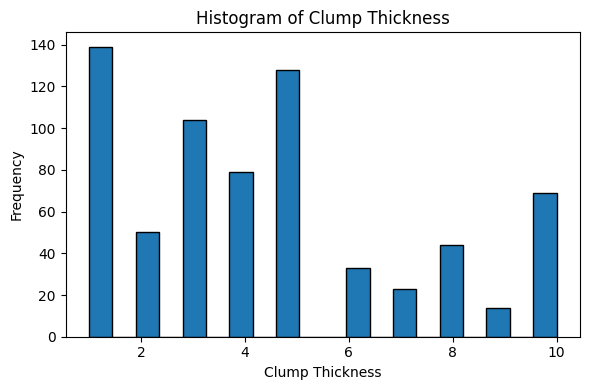

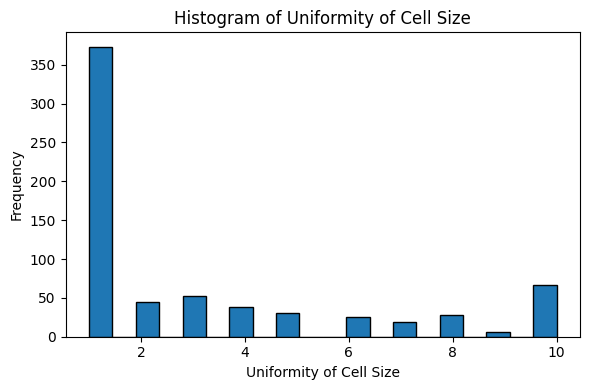

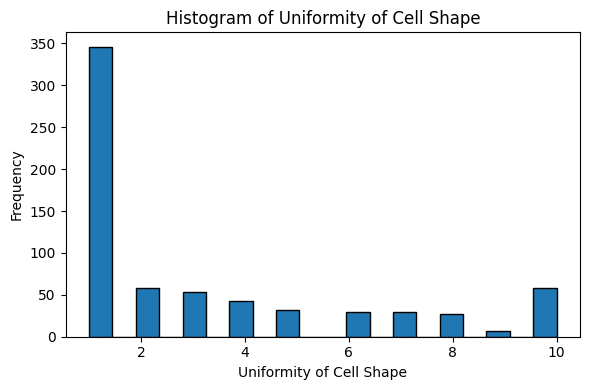

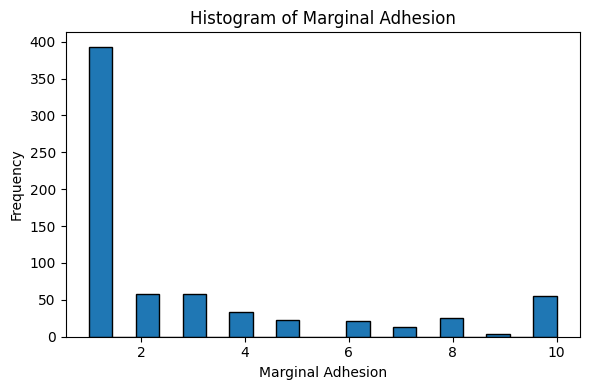

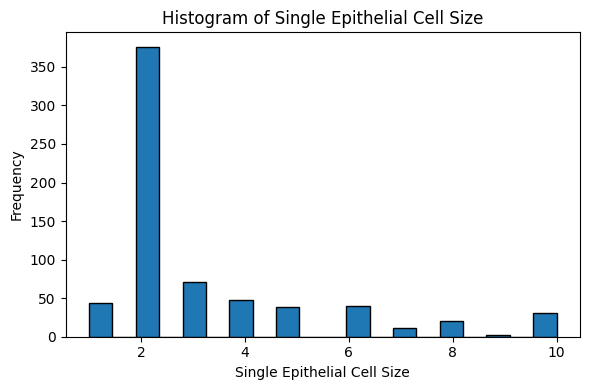

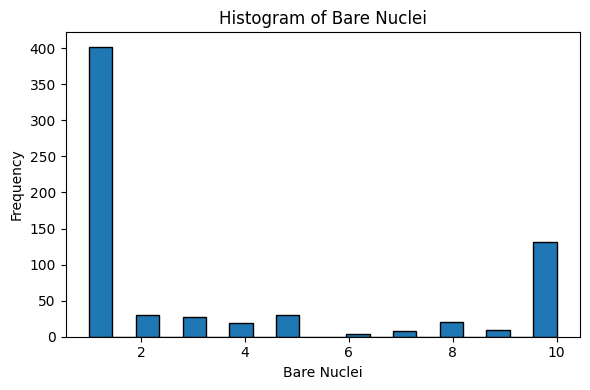

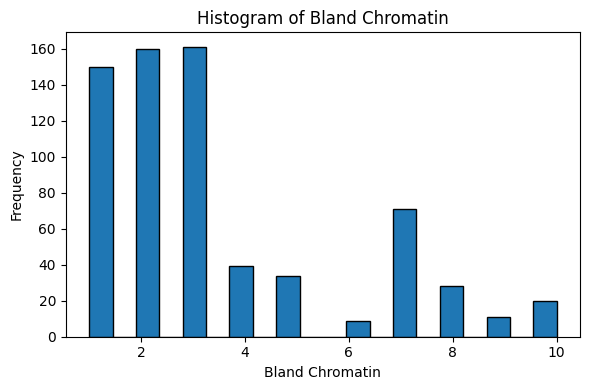

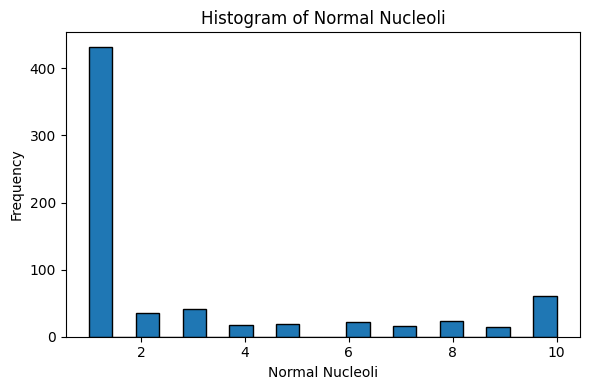

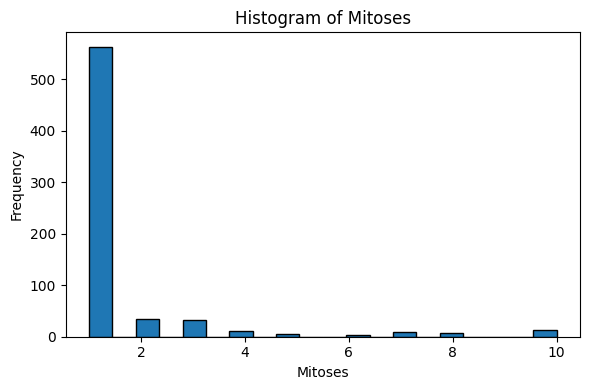

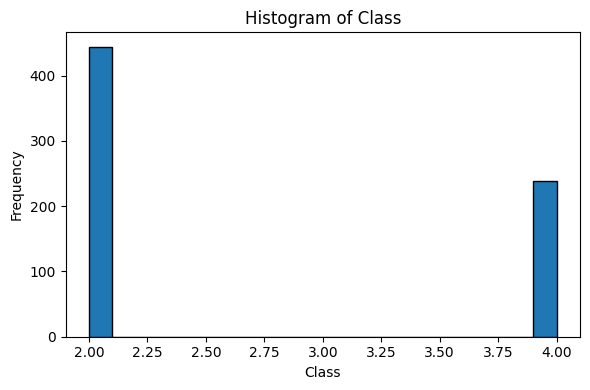

In [6]:
cols = breast_cancer.drop('Class', axis=1).columns

for col in breast_cancer.columns:
    fig, ax = plt.subplots(figsize=(6, 4))
    ax.hist(breast_cancer[col], bins=20, edgecolor='black')
    ax.set_title(f'Histogram of {col}')
    ax.set_xlabel(col)
    ax.set_ylabel('Frequency')
    plt.tight_layout()
    plt.show()

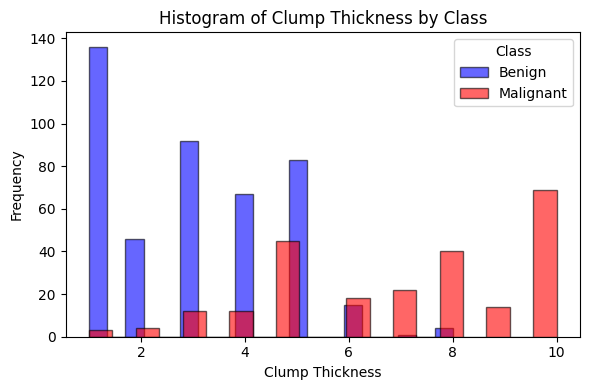

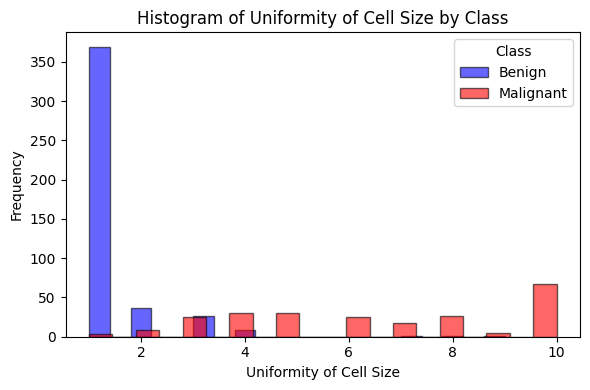

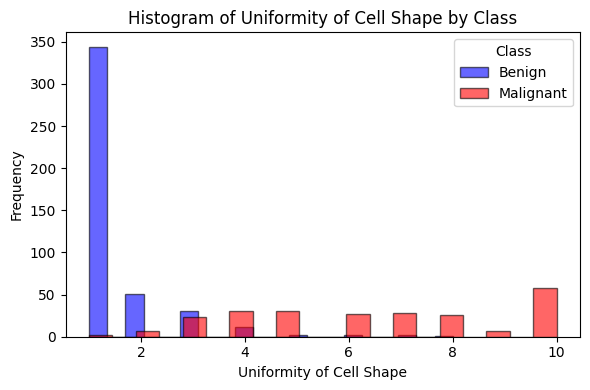

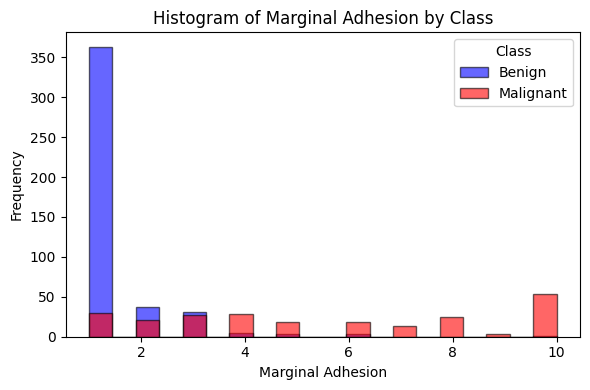

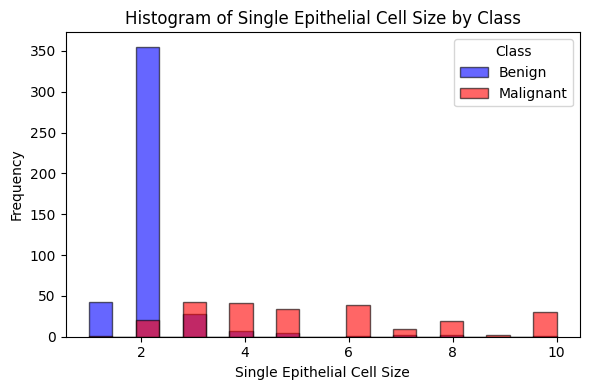

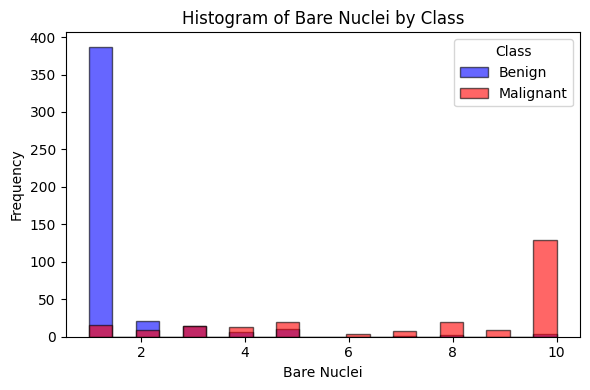

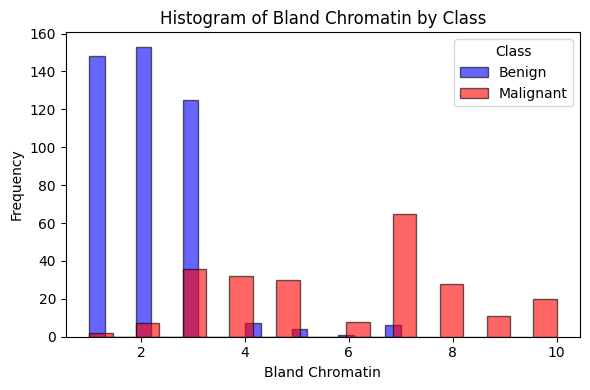

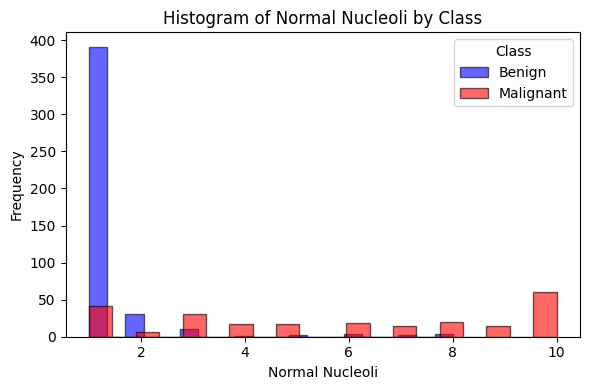

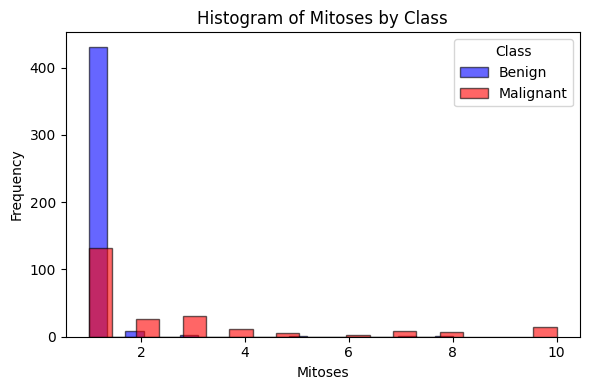

In [11]:
cols = breast_cancer.drop('Class', axis=1).columns

color_map = {2: 'blue', 4: 'red'}
label_map = {2: 'Benign', 4: 'Malignant'}

for col in cols:
    fig, ax = plt.subplots(figsize=(6, 4))
    for i in breast_cancer['Class'].unique():
        subset = breast_cancer[breast_cancer['Class'] == i]
        ax.hist(subset[col], bins=20, edgecolor='black', alpha=0.6,
                label=label_map[i], color=color_map[i])
    ax.set_title(f'Histogram of {col} by Class')
    ax.set_xlabel(col)
    ax.set_ylabel('Frequency')
    ax.legend(title='Class')
    plt.tight_layout()
    plt.show()

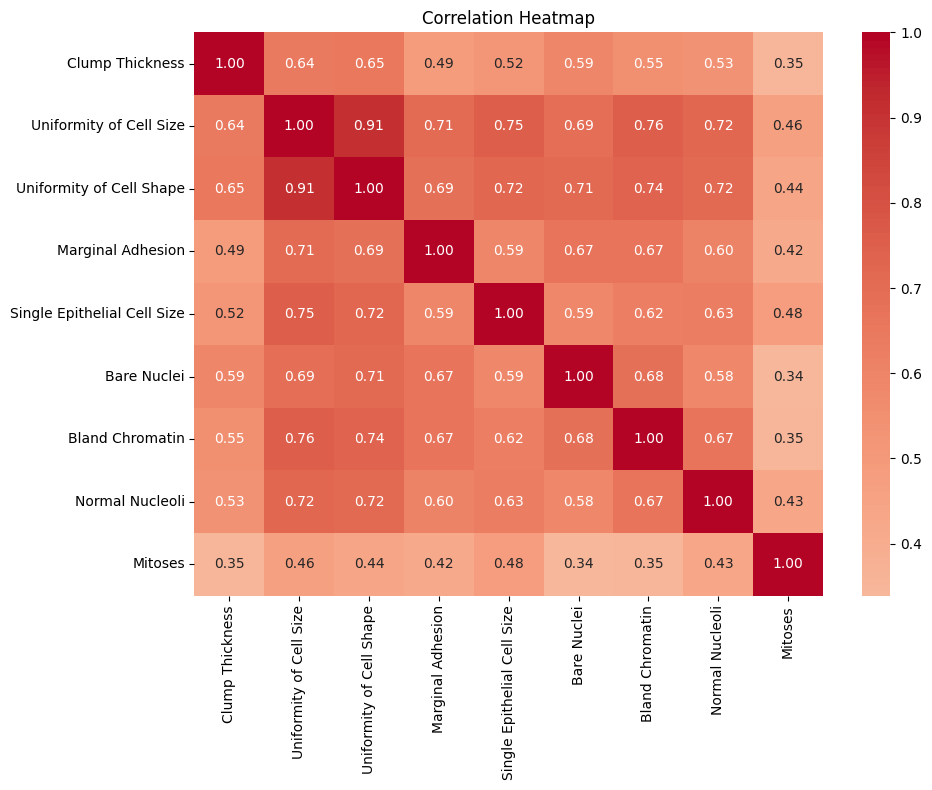

In [73]:
plt.figure(figsize=(10, 8))
sns.heatmap(breast_cancer.drop('Class', axis=1).corr(), annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('Correlation Heatmap')
plt.tight_layout()
plt.show()

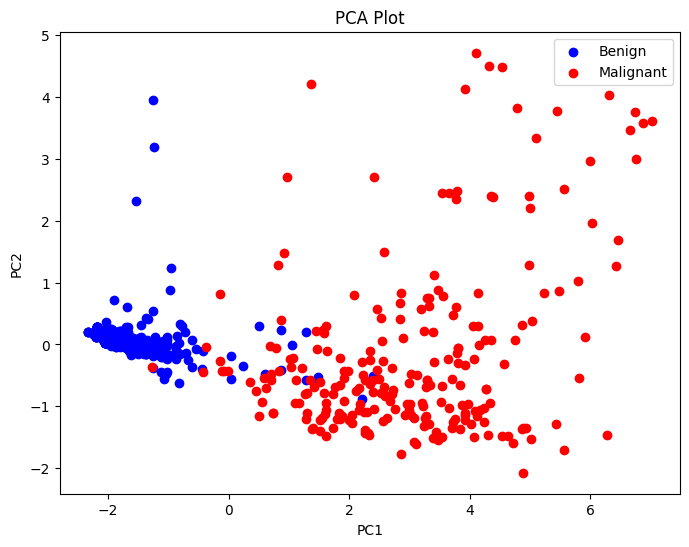

In [ ]:
X = breast_cancer.drop('Class', axis=1)
y = breast_cancer['Class']

X_scaled = StandardScaler().fit_transform(X)

# PCA
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

plt.figure(figsize=(8, 6))
plt.scatter(X_pca[y == 2, 0], X_pca[y == 2, 1], label='Benign', color='blue')
plt.scatter(X_pca[y == 4, 0], X_pca[y == 4, 1], label='Malignant', color='red')
plt.title('PCA Plot')
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.legend()
plt.show()

In [ ]:
pca1_var = pca.explained_variance_ratio_[0]
pca2_var = pca.explained_variance_ratio_[1]
pca_first_two_var = pca1_var + pca2_var

print(f"Percentage of variance explained by PC1: {pca1_var*100:.2f}%")
print(f"Percentage of variance explained by PC2: {pca2_var*100:.2f}%")
print(f"Percentage of varianced explained by PC1 & PC2: {pca_first_two_var*100:.2f}%")

Percentage of variance explained by PC1: 65.55%
Percentage of variance explained by PC2: 8.62%
Percentage of varianced explained by PC1 & PC2: 74.17%


# Assumptions:

## Linearity

/usr/local/lib/python3.12/dist-packages/statsmodels/nonparametric/smoothers_lowess.py:226: RuntimeWarning: invalid value encountered in divide
  res, _ = _lowess(y, x, x, np.ones_like(x),


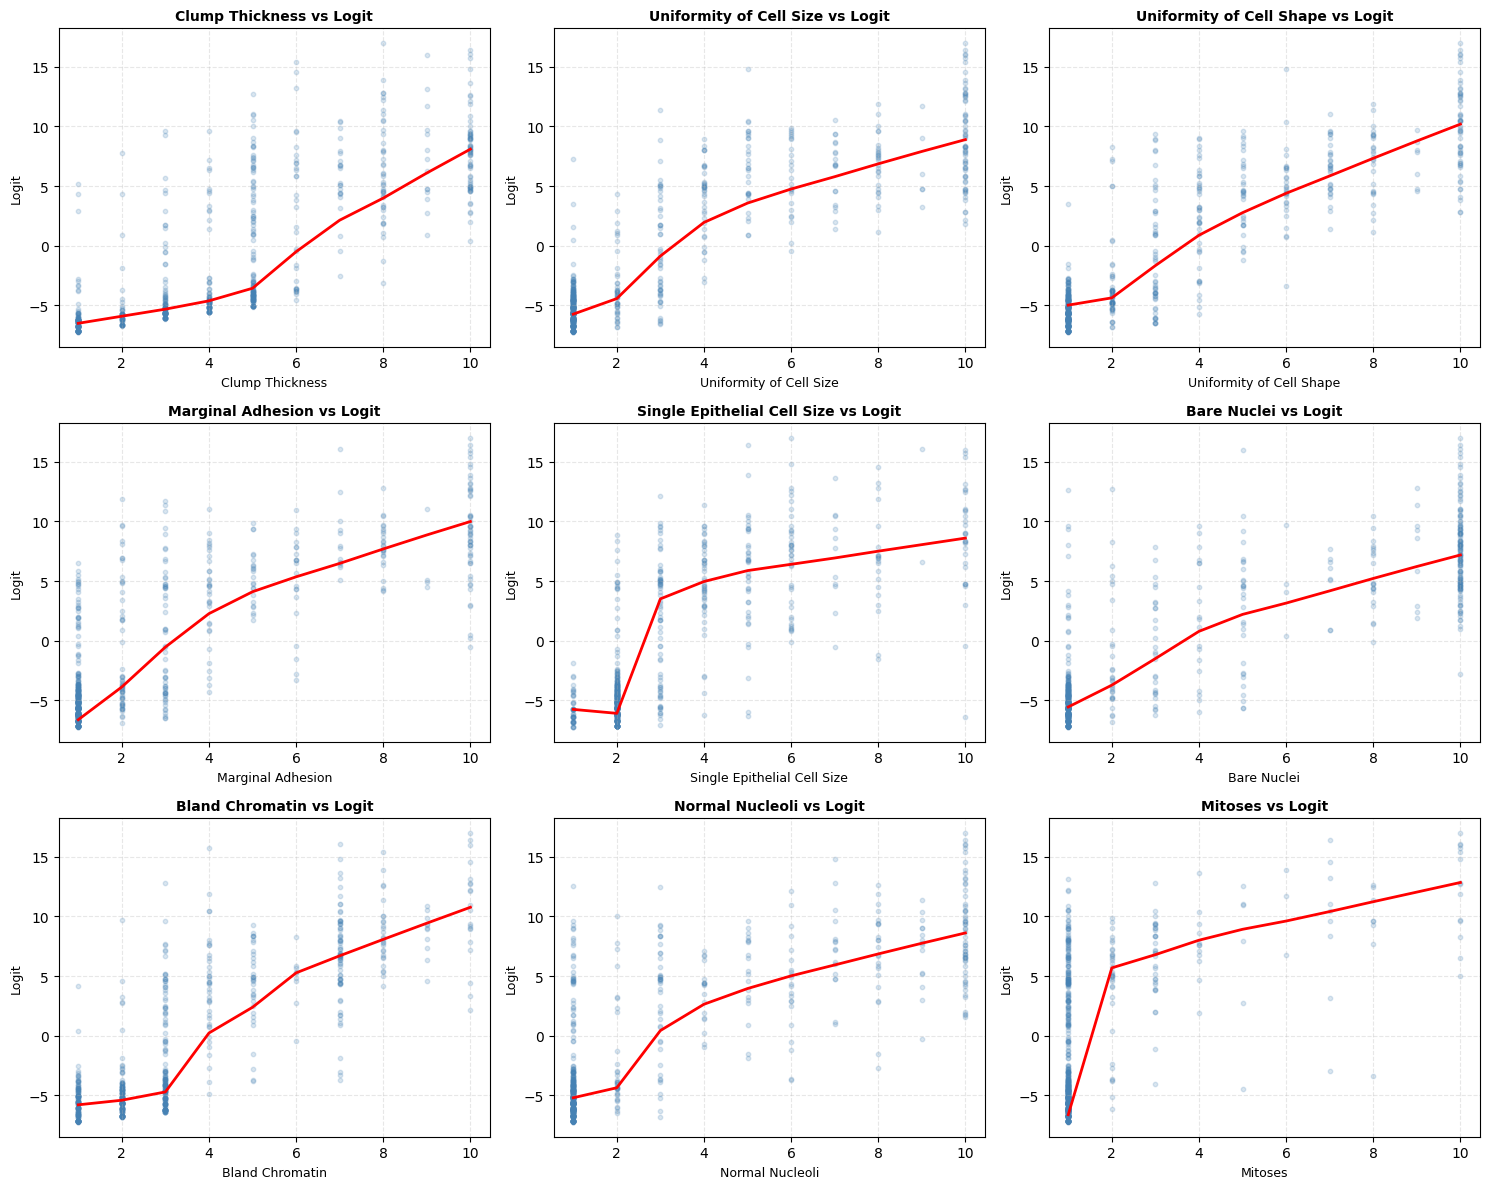

In [77]:
assumption_model = LogisticRegression(
    penalty=None,
    solver='lbfgs',
    max_iter=1000,
    random_state=399
)
assumption_model.fit(X, y)

# logit
log_odds_full = assumption_model.predict_proba(X)[:, 1]
logit_full = np.log(log_odds_full / (1 - log_odds_full))

# Plot each continuous predictor vs logit
n_cols = 3
n_rows = int(np.ceil(len(feature_names) / n_cols))
fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, n_rows * 4))
axes = axes.flatten()

for plot_i, feature in enumerate(feature_names):
    x_vals = X[:, plot_i]
    axes[plot_i].scatter(x_vals, logit_full, alpha=0.2, s=10, color='steelblue')
    smoothed = lowess(logit_full, x_vals, frac=0.5)
    axes[plot_i].plot(smoothed[:, 0], smoothed[:, 1], color='red', linewidth=2)
    axes[plot_i].set_xlabel(feature, fontsize=9)
    axes[plot_i].set_ylabel("Logit", fontsize=9)
    axes[plot_i].set_title(f"{feature} vs Logit", fontsize=10, fontweight='bold')
    axes[plot_i].grid(True, linestyle='--', alpha=0.3)

for j in range(plot_i + 1, len(axes)):
    axes[j].set_visible(False)

plt.tight_layout()
plt.show()

## Multicollinearity

In [79]:
vif_data = pd.DataFrame()
vif_data['Feature'] = feature_names
vif_data['VIF'] = [variance_inflation_factor(X, i) for i in range(X.shape[1])]

print(vif_data.sort_values('VIF', ascending=False).to_string(index=False))

                    Feature       VIF
   Uniformity of Cell Shape 14.131730
    Uniformity of Cell Size 13.991156
            Bland Chromatin  7.526238
Single Epithelial Cell Size  6.879037
            Clump Thickness  5.194380
                Bare Nuclei  4.984470
          Marginal Adhesion  4.874432
            Normal Nucleoli  4.534766
                    Mitoses  2.560638


## Outliers

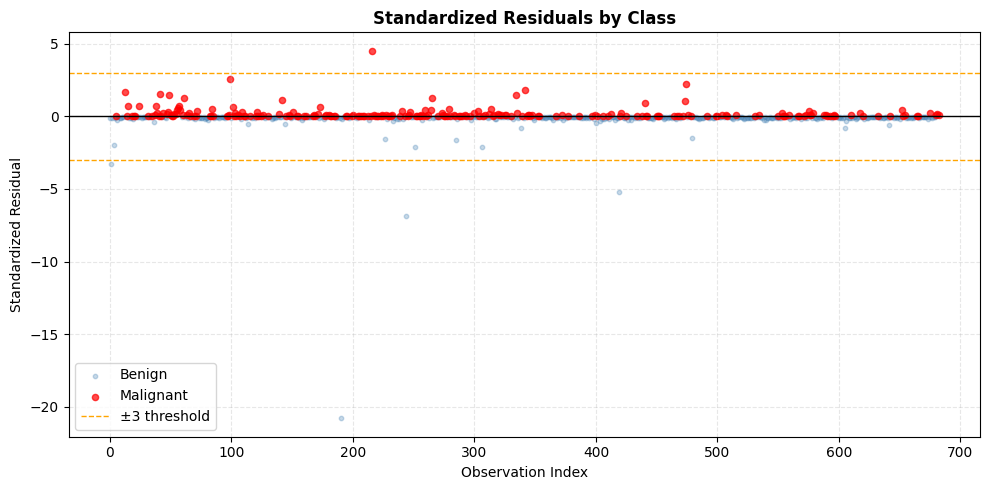


Number of outliers (|std resid| > 3): 5
  Malignant outliers: 1
  Benign outliers:    4


In [82]:
X_sm = sm.add_constant(X.astype(float))
sm_model = sm.Logit(y, X_sm)
sm_result = sm_model.fit(maxiter=1000, disp=False)

# Standardized Residuals
influence = sm_result.get_influence()
std_resid = influence.resid_studentized

benign_idx    = np.where(y == 0)[0]
malignant_idx = np.where(y == 1)[0]

fig, ax = plt.subplots(figsize=(10, 5))
ax.scatter(benign_idx, std_resid[benign_idx],
           alpha=0.3, s=10, color='steelblue', label='Benign')
ax.scatter(malignant_idx, std_resid[malignant_idx],
           alpha=0.7, s=20, color='red', label='Malignant')
ax.axhline(y=0,  color='black', linewidth=1, linestyle='-')
ax.axhline(y=3,  color='orange', linewidth=1, linestyle='--', label='±3 threshold')
ax.axhline(y=-3, color='orange', linewidth=1, linestyle='--')
ax.set_title("Standardized Residuals by Class", fontweight='bold')
ax.set_xlabel("Observation Index")
ax.set_ylabel("Standardized Residual")
ax.legend()
ax.grid(True, linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()

outliers        = np.where(np.abs(std_resid) > 3)[0]
out_malignant   = np.sum(y[outliers] == 1)
out_benign      = np.sum(y[outliers] == 0)
print(f"\nNumber of outliers (|std resid| > 3): {len(outliers)}")
print(f"  Malignant outliers: {out_malignant}")
print(f"  Benign outliers:    {out_benign}")

# Train / Test Split

In [14]:
X = breast_cancer.drop('Class', axis=1).values
y = breast_cancer['Class'].map({2: 0, 4: 1}).values
# Now Benign=0 & Malignant=1

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=399)

# Logistic Regression w/ Cross Validation for Ridge & Lasso

In [18]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Ridge

In [71]:
ridge_params = [0.001, 0.01, 0.1, 0.5, 1, 5, 10, 20, 50, 100]

kf = KFold(n_splits=5, shuffle=True, random_state=399)

ridge_acc_means = []
ridge_fold_scores = []

print("Cross-Validation Results:")
print("-" * 70)

for C in ridge_params:
    model = LogisticRegression(penalty='l2', C=C, random_state=399)
    scores = cross_val_score(model, X_train_scaled, y_train, cv=kf, scoring='accuracy')
    ridge_fold_scores.append(scores)
    mean_acc = scores.mean()
    ridge_acc_means.append(mean_acc)
    print(f"CV Accuracy with Ridge Regularization C = {C}, CV mean accuracy = {mean_acc:.4f}")

print("-" * 70)

best_idx = np.argmax(ridge_acc_means)
chosen_C_ridge = ridge_params[best_idx]

print(f"Best CV Accuracy: {ridge_acc_means[best_idx]:.4f}")
print(f"Best C: {chosen_C_ridge}")

Cross-Validation Results:
----------------------------------------------------------------------
CV Accuracy with Ridge Regularization C = 0.001, CV mean accuracy = 0.8845
CV Accuracy with Ridge Regularization C = 0.01, CV mean accuracy = 0.9542
CV Accuracy with Ridge Regularization C = 0.1, CV mean accuracy = 0.9652
CV Accuracy with Ridge Regularization C = 0.5, CV mean accuracy = 0.9634
CV Accuracy with Ridge Regularization C = 1, CV mean accuracy = 0.9634
CV Accuracy with Ridge Regularization C = 5, CV mean accuracy = 0.9616
CV Accuracy with Ridge Regularization C = 10, CV mean accuracy = 0.9616
CV Accuracy with Ridge Regularization C = 20, CV mean accuracy = 0.9616
CV Accuracy with Ridge Regularization C = 50, CV mean accuracy = 0.9616
CV Accuracy with Ridge Regularization C = 100, CV mean accuracy = 0.9616
----------------------------------------------------------------------
Best CV Accuracy: 0.9652
Best C: 0.1


In [85]:
ridge_params_refined = [0.05, 0.075, 0.1, 0.125, 0.15, 0.2, 0.25, 0.3, 0.35, 0.4, 0.45, 0.5]

kf = KFold(n_splits=5, shuffle=True, random_state=399)

ridge_acc_means_refined = []
ridge_fold_scores_refined = []

print("Cross-Validation Results:")
print("-" * 70)

for C in ridge_params_refined:
    model = LogisticRegression(penalty='l2', C=C, random_state=399)
    scores = cross_val_score(model, X_train_scaled, y_train, cv=kf, scoring='accuracy')
    ridge_fold_scores_refined.append(scores)
    mean_acc = scores.mean()
    ridge_acc_means_refined.append(mean_acc)
    print(f"CV Accuracy with Ridge Regularization C = {C}, CV mean accuracy = {mean_acc:.4f}")

print("-" * 70)

best_idx = np.argmax(ridge_acc_means_refined)
chosen_C_ridge = ridge_params_refined[best_idx]

print(f"Best CV Accuracy: {ridge_acc_means_refined[best_idx]:.4f}")
print(f"Best C: {chosen_C_ridge}")

Cross-Validation Results:
----------------------------------------------------------------------
CV Accuracy with Ridge Regularization C = 0.05, CV mean accuracy = 0.9616
CV Accuracy with Ridge Regularization C = 0.075, CV mean accuracy = 0.9634
CV Accuracy with Ridge Regularization C = 0.1, CV mean accuracy = 0.9652
CV Accuracy with Ridge Regularization C = 0.125, CV mean accuracy = 0.9652
CV Accuracy with Ridge Regularization C = 0.15, CV mean accuracy = 0.9652
CV Accuracy with Ridge Regularization C = 0.2, CV mean accuracy = 0.9652
CV Accuracy with Ridge Regularization C = 0.25, CV mean accuracy = 0.9652
CV Accuracy with Ridge Regularization C = 0.3, CV mean accuracy = 0.9652
CV Accuracy with Ridge Regularization C = 0.35, CV mean accuracy = 0.9634
CV Accuracy with Ridge Regularization C = 0.4, CV mean accuracy = 0.9634
CV Accuracy with Ridge Regularization C = 0.45, CV mean accuracy = 0.9634
CV Accuracy with Ridge Regularization C = 0.5, CV mean accuracy = 0.9634
------------------

In [61]:
feature_names = breast_cancer.drop('Class', axis=1).columns

print(f"Best C: {chosen_C}")

final_model = LogisticRegression(penalty='l2', C=chosen_C, random_state=399)
final_model.fit(X_train_scaled, y_train)

print(f"\nIntercept of final Logistic Regression with Ridge model: {final_model.intercept_[0]:.3f}")
print(f"Number of non-zero coefficients: {np.sum(final_model.coef_ != 0)}")

print("\nCoefficients:")
for feature, coef in zip(feature_names, final_model.coef_[0]):
    print(f"  {feature}: {coef:.4f}")

Best C: 0.1

Intercept of final Logistic Regression with Ridge model: -0.882
Number of non-zero coefficients: 9

Coefficients:
  Clump Thickness: 0.8088
  Uniformity of Cell Size: 0.5449
  Uniformity of Cell Shape: 0.6036
  Marginal Adhesion: 0.5514
  Single Epithelial Cell Size: 0.3169
  Bare Nuclei: 0.9053
  Bland Chromatin: 0.5273
  Normal Nucleoli: 0.4136
  Mitoses: 0.3635


Train Accuracy: 0.9670


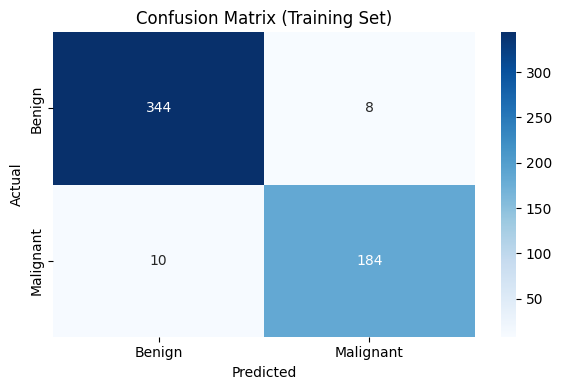

In [62]:
y_pred_train = final_model.predict(X_train_scaled)

print(f"Train Accuracy: {final_model.score(X_train_scaled, y_train):.4f}")

cm_train = confusion_matrix(y_train, y_pred_train)

plt.figure(figsize=(6, 4))
sns.heatmap(cm_train, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Benign', 'Malignant'],
            yticklabels=['Benign', 'Malignant'])
plt.title('Confusion Matrix (Training Set)')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()
plt.show()

Test Accuracy: 0.9927


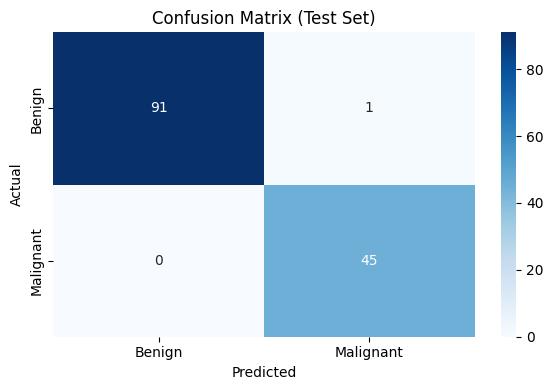

In [63]:
y_pred = final_model.predict(X_test_scaled)

print(f"Test Accuracy: {final_model.score(X_test_scaled, y_test):.4f}")

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Benign', 'Malignant'],
            yticklabels=['Benign', 'Malignant'])
plt.title('Confusion Matrix (Test Set)')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()
plt.show()

# Lasso

In [83]:
lasso_params = [0.001, 0.01, 0.1, 0.5, 1, 5, 10, 20, 50, 100]

kf = KFold(n_splits=5, shuffle=True, random_state=399)

lasso_acc_means = []
lasso_acc_ses = []
lasso_fold_scores = []

print("Cross-Validation Results:")
print("-" * 70)

for C in lasso_params:
    model = LogisticRegression(penalty='l1', C=C, solver='liblinear', random_state=399)
    scores = cross_val_score(model, X_train_scaled, y_train, cv=kf, scoring='accuracy')
    lasso_fold_scores.append(scores)
    mean_acc = scores.mean()
    se_acc = scores.std() / np.sqrt(len(scores))
    lasso_acc_means.append(mean_acc)
    lasso_acc_ses.append(se_acc)
    print(f"CV Accuracy with Lasso Regularization C = {C}, CV mean accuracy {mean_acc:.4f} (SE = {se_acc:.4f})")

print("-" * 70)

best_idx = np.argmax(lasso_acc_means)
best_acc = lasso_acc_means[best_idx]
best_se = lasso_acc_ses[best_idx]

# 1-SE rule
threshold = best_acc - best_se
within_1se = [i for i, acc in enumerate(lasso_acc_means) if acc >= threshold]
chosen_idx = within_1se[0]
chosen_C_lasso = lasso_params[chosen_idx]

print(f"Simplest model within 1-SE of best accuracy: C = {chosen_C_lasso}")
print(f"Best CV Accuracy: {best_acc:.4f}")
print(f"Chosen model CV Accuracy: {lasso_acc_means[chosen_idx]:.4f}")

Cross-Validation Results:
----------------------------------------------------------------------
CV Accuracy with Lasso Regularization C = 0.001, CV mean accuracy 0.6446 (SE = 0.0203)
CV Accuracy with Lasso Regularization C = 0.01, CV mean accuracy 0.9616 (SE = 0.0070)
CV Accuracy with Lasso Regularization C = 0.1, CV mean accuracy 0.9616 (SE = 0.0070)
CV Accuracy with Lasso Regularization C = 0.5, CV mean accuracy 0.9634 (SE = 0.0082)
CV Accuracy with Lasso Regularization C = 1, CV mean accuracy 0.9634 (SE = 0.0082)
CV Accuracy with Lasso Regularization C = 5, CV mean accuracy 0.9616 (SE = 0.0070)
CV Accuracy with Lasso Regularization C = 10, CV mean accuracy 0.9616 (SE = 0.0070)
CV Accuracy with Lasso Regularization C = 20, CV mean accuracy 0.9616 (SE = 0.0070)
CV Accuracy with Lasso Regularization C = 50, CV mean accuracy 0.9616 (SE = 0.0070)
CV Accuracy with Lasso Regularization C = 100, CV mean accuracy 0.9616 (SE = 0.0070)
---------------------------------------------------------

In [84]:
lasso_params_refined = [0.005, 0.0075, 0.01, 0.025, 0.05, 0.075, 0.1, 0.125, 0.15]

kf = KFold(n_splits=5, shuffle=True, random_state=399)

lasso_acc_means_refined = []
lasso_acc_ses_refined = []
lasso_fold_scores_refined = []

print("Cross-Validation Results:")
print("-" * 70)

for C in lasso_params_refined:
    model = LogisticRegression(penalty='l1', C=C, solver='liblinear', random_state=399)
    scores = cross_val_score(model, X_train_scaled, y_train, cv=kf, scoring='accuracy')
    lasso_fold_scores_refined.append(scores)
    mean_acc = scores.mean()
    se_acc = scores.std() / np.sqrt(len(scores))
    lasso_acc_means_refined.append(mean_acc)
    lasso_acc_ses_refined.append(se_acc)
    print(f"CV Accuracy with Lasso Regularization C = {C}, CV mean accuracy {mean_acc:.4f} (SE = {se_acc:.4f})")

print("-" * 70)

best_idx = np.argmax(lasso_acc_means_refined)
best_acc = lasso_acc_means_refined[best_idx]
best_se = lasso_acc_ses_refined[best_idx]

# 1-SE rule
threshold = best_acc - best_se
within_1se = [i for i, acc in enumerate(lasso_acc_means_refined) if acc >= threshold]
chosen_idx = within_1se[0]
chosen_C_lasso = lasso_params_refined[chosen_idx]

print(f"Simplest model within 1-SE of best accuracy: C = {chosen_C_lasso}")
print(f"Best CV Accuracy: {best_acc:.4f}")
print(f"Chosen model CV Accuracy: {lasso_acc_means_refined[chosen_idx]:.4f}")

Cross-Validation Results:
----------------------------------------------------------------------
CV Accuracy with Lasso Regularization C = 0.005, CV mean accuracy 0.6446 (SE = 0.0203)
CV Accuracy with Lasso Regularization C = 0.0075, CV mean accuracy 0.9597 (SE = 0.0071)
CV Accuracy with Lasso Regularization C = 0.01, CV mean accuracy 0.9616 (SE = 0.0070)
CV Accuracy with Lasso Regularization C = 0.025, CV mean accuracy 0.9671 (SE = 0.0066)
CV Accuracy with Lasso Regularization C = 0.05, CV mean accuracy 0.9634 (SE = 0.0078)
CV Accuracy with Lasso Regularization C = 0.075, CV mean accuracy 0.9616 (SE = 0.0070)
CV Accuracy with Lasso Regularization C = 0.1, CV mean accuracy 0.9616 (SE = 0.0070)
CV Accuracy with Lasso Regularization C = 0.125, CV mean accuracy 0.9634 (SE = 0.0082)
CV Accuracy with Lasso Regularization C = 0.15, CV mean accuracy 0.9634 (SE = 0.0082)
----------------------------------------------------------------------
Simplest model within 1-SE of best accuracy: C = 0.01

In [67]:
feature_names = breast_cancer.drop('Class', axis=1).columns

print(f"Best C: {chosen_C}")

final_model = LogisticRegression(penalty='l2', C=chosen_C, random_state=399)
final_model.fit(X_train_scaled, y_train)

print(f"\nIntercept of final Logistic Regression with Lasso model: {final_model.intercept_[0]:.3f}")
print(f"Number of non-zero coefficients: {np.sum(final_model.coef_ != 0)}")

print("\nCoefficients:")
for feature, coef in zip(feature_names, final_model.coef_[0]):
    print(f"  {feature}: {coef:.4f}")

Best C: 0.01

Intercept of final Logistic Regression with Lasso model: -0.799
Number of non-zero coefficients: 9

Coefficients:
  Clump Thickness: 0.3768
  Uniformity of Cell Size: 0.3382
  Uniformity of Cell Shape: 0.3459
  Marginal Adhesion: 0.2844
  Single Epithelial Cell Size: 0.2480
  Bare Nuclei: 0.4398
  Bland Chromatin: 0.3134
  Normal Nucleoli: 0.2802
  Mitoses: 0.1588


Train Accuracy: 0.9579


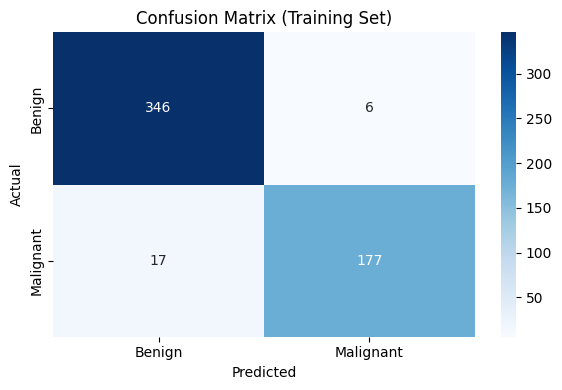

In [68]:
y_pred_train = final_model.predict(X_train_scaled)

print(f"Train Accuracy: {final_model.score(X_train_scaled, y_train):.4f}")

cm_train = confusion_matrix(y_train, y_pred_train)

plt.figure(figsize=(6, 4))
sns.heatmap(cm_train, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Benign', 'Malignant'],
            yticklabels=['Benign', 'Malignant'])
plt.title('Confusion Matrix (Training Set)')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()
plt.show()

Test Accuracy: 0.9781


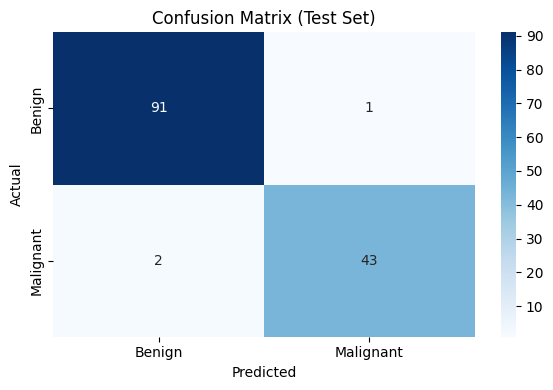

In [69]:
y_pred = final_model.predict(X_test_scaled)

print(f"Test Accuracy: {final_model.score(X_test_scaled, y_test):.4f}")

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Benign', 'Malignant'],
            yticklabels=['Benign', 'Malignant'])
plt.title('Confusion Matrix (Test Set)')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()
plt.show()

/tmp/ipykernel_19963/2351167744.py:4: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[0].boxplot(ridge_fold_scores_refined,
/tmp/ipykernel_19963/2351167744.py:18: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[1].boxplot(lasso_fold_scores_refined,


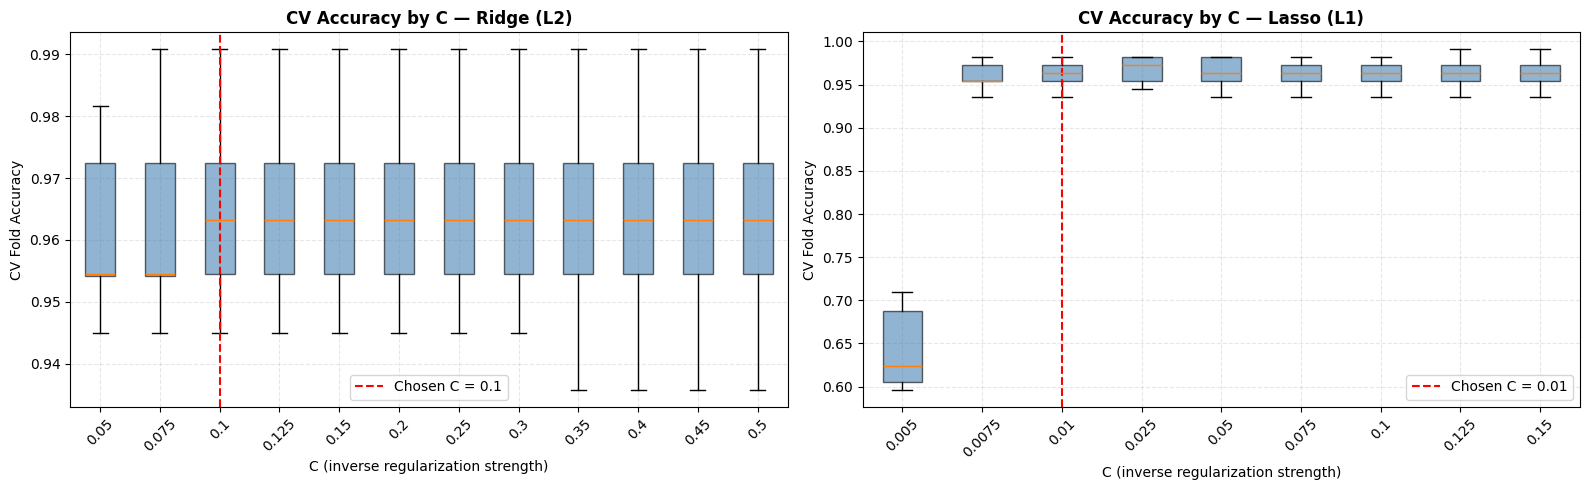

In [86]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Ridge
axes[0].boxplot(ridge_fold_scores_refined,
                labels=[str(c) for c in ridge_params_refined],
                patch_artist=True,
                boxprops=dict(facecolor='steelblue', alpha=0.6))
axes[0].axvline(x=ridge_params_refined.index(chosen_C_ridge) + 1,
                color='red', linestyle='--', label=f'Chosen C = {chosen_C_ridge}')
axes[0].set_xlabel('C (inverse regularization strength)', fontsize=10)
axes[0].set_ylabel('CV Fold Accuracy', fontsize=10)
axes[0].set_title('CV Accuracy by C — Ridge (L2)', fontweight='bold')
axes[0].tick_params(axis='x', rotation=45)
axes[0].legend()
axes[0].grid(True, linestyle='--', alpha=0.3)

# Lasso
axes[1].boxplot(lasso_fold_scores_refined,
                labels=[str(c) for c in lasso_params_refined],
                patch_artist=True,
                boxprops=dict(facecolor='steelblue', alpha=0.6))
axes[1].axvline(x=lasso_params_refined.index(chosen_C_lasso) + 1,
                color='red', linestyle='--', label=f'Chosen C = {chosen_C_lasso}')
axes[1].set_xlabel('C (inverse regularization strength)', fontsize=10)
axes[1].set_ylabel('CV Fold Accuracy', fontsize=10)
axes[1].set_title('CV Accuracy by C — Lasso (L1)', fontweight='bold')
axes[1].tick_params(axis='x', rotation=45)
axes[1].legend()
axes[1].grid(True, linestyle='--', alpha=0.3)

plt.tight_layout()
plt.show()

# Linear Discriminant Analysis

In [ ]:
X_B = X_train[y_train == 0]  # Benign group
X_M = X_train[y_train == 1]  # Malignant group

X_bar_B = X_B.mean(axis=0)
X_bar_M = X_M.mean(axis=0)

N = len(y_train)
n_B = len(X_B)
n_M = len(X_M)
p = X_train.shape[1]

my_matrix = np.zeros((p, p))

for i in range(n_B):
    diff = X_B[i] - X_bar_B
    my_matrix = my_matrix + np.outer(diff, diff)

for i in range(n_M):
    diff = X_M[i] - X_bar_M
    my_matrix = my_matrix + np.outer(diff, diff)

Ehat = my_matrix / (N - 2)
print("Ehat:")
print(Ehat)

print("\nDiagonal of Ehat:")
print(np.diag(Ehat))

sqrt_diag = np.sqrt(np.diag(Ehat))

# Normalize each variable by within-group standard deviation (Train & Test)
X_train_norm = X_train / sqrt_diag
X_test_norm = X_test / sqrt_diag

Ehat:
[[ 3.97987627  0.40683382  0.51089315 -0.31373208  0.12191569  0.04803095
   0.10688931  0.17894906  0.17347974]
 [ 0.40683382  3.11119945  2.14795921  1.04294851  1.34983819 -0.0646365
   0.98535399  1.24300454  0.62590081]
 [ 0.51089315  2.14795921  3.0312353   0.86350505  1.13030695  0.23809481
   0.77117082  1.17771769  0.48443987]
 [-0.31373208  1.04294851  0.86350505  4.14919763  0.61812315  0.83157164
   1.04456461  0.83890396  0.67018939]
 [ 0.12191569  1.34983819  1.13030695  0.61812315  2.78508707  0.15264411
   0.59739837  1.05812342  0.76244809]
 [ 0.04803095 -0.0646365   0.23809481  0.83157164  0.15264411  4.46414445
   0.56752231 -0.06839265 -0.07631309]
 [ 0.10688931  0.98535399  0.77117082  1.04456461  0.59739837  0.56752231
   2.63569756  0.85825302  0.07931751]
 [ 0.17894906  1.24300454  1.17771769  0.83890396  1.05812342 -0.06839265
   0.85825302  4.74181925  0.82421961]
 [ 0.17347974  0.62590081  0.48443987  0.67018939  0.76244809 -0.07631309
   0.07931751  0.

# LDA on Training Data

In [ ]:
lda = LinearDiscriminantAnalysis()
lda.fit(X_train_norm, y_train)

lda_train_predictions = lda.predict(X_train_norm)

lda_confusion_matrix = pd.crosstab(y_train, lda_train_predictions, rownames=['Actual'], colnames=['Predicted'])
print(lda_confusion_matrix)

correct = sum(lda_train_predictions == y_train)
total = len(y_train)
accuracy = correct / total * 100

print(f"\nTraining percentage of data points predicted correctly:")
print(f"{accuracy:.2f}%")

Predicted    0    1
Actual             
0          345    7
1           16  178

Training percentage of data points predicted correctly:
95.79%


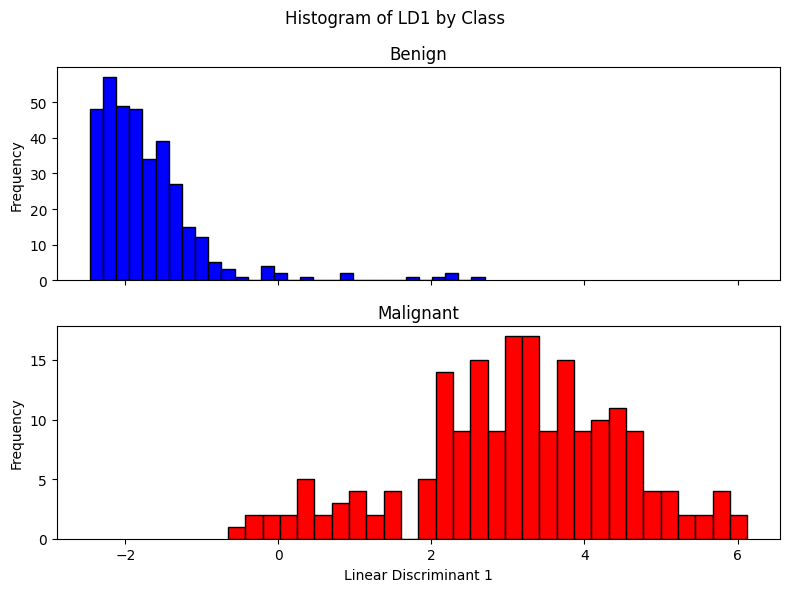

In [ ]:
# LDA for graphing
LD1_train = lda.transform(X_train_norm).flatten()

fig, axes = plt.subplots(2, 1, figsize=(8, 6), sharex=True)

axes[0].hist(LD1_train[y_train == 0], bins=30, color='blue', edgecolor='black')
axes[0].set_title('Benign')
axes[0].set_ylabel('Frequency')

axes[1].hist(LD1_train[y_train == 1], bins=30, color='red', edgecolor='black')
axes[1].set_title('Malignant')
axes[1].set_ylabel('Frequency')

plt.suptitle('Histogram of LD1 by Class')
plt.xlabel('Linear Discriminant 1')
plt.tight_layout()
plt.show()

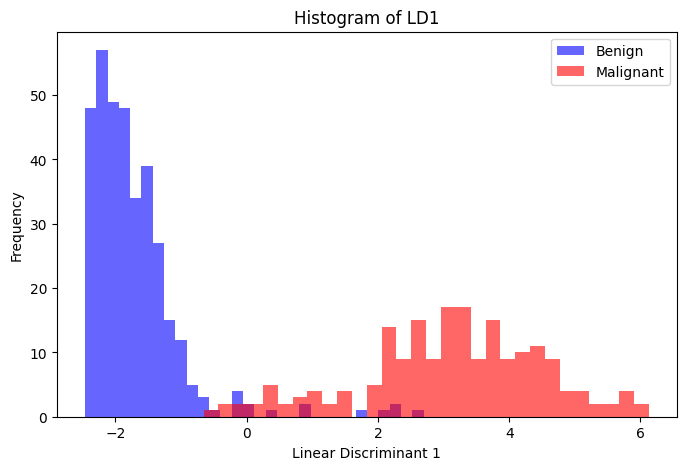

In [ ]:
plt.figure(figsize=(8, 5))
plt.hist(LD1_train[y_train == 0], bins=30, alpha=0.6, label='Benign', color='blue')
plt.hist(LD1_train[y_train == 1], bins=30, alpha=0.6, label='Malignant', color='red')
plt.title('Histogram of LD1')
plt.xlabel('Linear Discriminant 1')
plt.ylabel('Frequency')
plt.legend()
plt.show()

# LDA on Test Data

In [ ]:
lda_test_predictions = lda.predict(X_test_norm)

lda_test_confusion_matrix = pd.crosstab(y_test, lda_test_predictions, rownames=['Actual'], colnames=['Predicted'])
print(lda_test_confusion_matrix)

correct = sum(lda_test_predictions == y_test)
total = len(y_test)
accuracy = correct / total * 100

print(f"\nTesting percentage of data points predicted correctly:")
print(f"{accuracy:.2f}%")

Predicted   0   1
Actual           
0          91   1
1           2  43

Testing percentage of data points predicted correctly:
97.81%


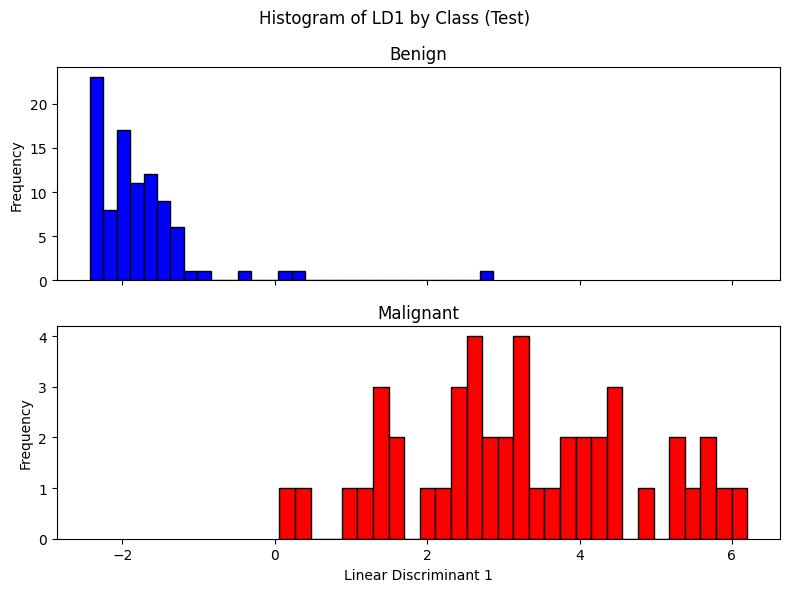

In [ ]:
# LDA for graphing (Test)
LD1_test = lda.transform(X_test_norm).flatten()

fig, axes = plt.subplots(2, 1, figsize=(8, 6), sharex=True)

axes[0].hist(LD1_test[y_test == 0], bins=30, color='blue', edgecolor='black')
axes[0].set_title('Benign')
axes[0].set_ylabel('Frequency')

axes[1].hist(LD1_test[y_test == 1], bins=30, color='red', edgecolor='black')
axes[1].set_title('Malignant')
axes[1].set_ylabel('Frequency')

plt.suptitle('Histogram of LD1 by Class (Test)')
plt.xlabel('Linear Discriminant 1')
plt.tight_layout()
plt.show()

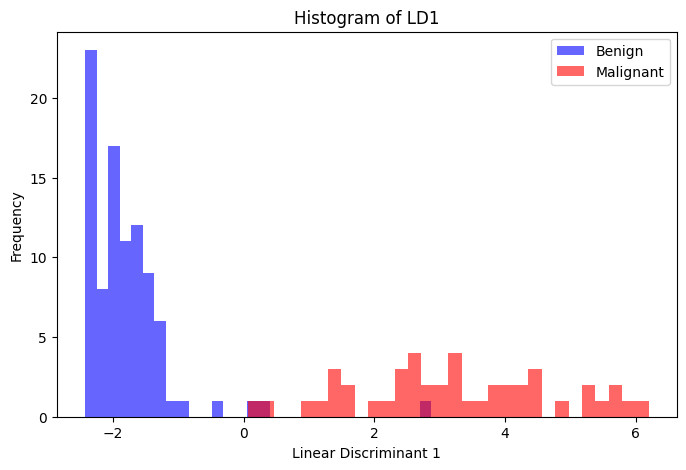

In [ ]:
plt.figure(figsize=(8, 5))
plt.hist(LD1_test[y_test == 0], bins=30, alpha=0.6, label='Benign', color='blue')
plt.hist(LD1_test[y_test == 1], bins=30, alpha=0.6, label='Malignant', color='red')
plt.title('Histogram of LD1')
plt.xlabel('Linear Discriminant 1')
plt.ylabel('Frequency')
plt.legend()
plt.show()